# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [120]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def entropy(k: np.array) -> float:
    all_count = np.sum(k)
    p = k / all_count
    p = p[p > 0] # проверка для логарифма
    p = p * np.log(p)
    return -np.sum(p)

all_obj = np.array([8, 2])
print(np.round(entropy(all_obj), 2))

0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [121]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
def H(r: np.array) -> float:
    total = np.sum(r)
    if total == 0:
        return 0
    p = r / total
    res = np.sum(p * (1 - p))
    return res

def Q(rl: np.array, rr: np.array) -> float:
    rm = rl + rr
    size_rm = sum(rm)
    size_rl = sum(rl)
    size_rr = sum(rr)
    if size_rm == 0:
        return 0
    return H(rm) - (size_rl / size_rm) * H(rl) - (size_rr / size_rm) * H(rr)

rl = np.array([8, 0])
rr = np.array([0, 2])

q = np.round(Q(rl, rr), 2)
print(q)


0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [24]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
leaf_values = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]
mean1 = sum(leaf_values) / len(leaf_values)
# или если можно использовать np.mean
#mean2 = np.mean(leaf_values)
print(mean1)


40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [25]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [ ]:

def QGiniReal(sorted_target, split_inds, n):
    # подобие one-hot по классам
    unique_target = np.unique(sorted_target)
    target_one_hot = (sorted_target.reshape(-1, 1) == unique_target.reshape(1, -1)).astype(float)
    cumsum = np.cumsum(target_one_hot, axis=0)
    count_left = cumsum[split_inds - 1]
    count_total = cumsum[-1].reshape(1, -1)
    count_right = count_total - count_left

    n_left = split_inds.reshape(-1, 1)
    n_right = n - n_left

    gini_left = 1 - np.sum((count_left / n_left) ** 2, axis=1)
    gini_right = 1 - np.sum((count_right / n_right) ** 2, axis=1)
    gini_split = (n_left.flatten() / n) * gini_left + (n_right.flatten() / n) * gini_right
    return 1 - np.sum((count_total.flatten() / n) ** 2) - gini_split

def QVarReal(sorted_target, split_inds, n):
    cumsum_targets = np.cumsum(sorted_target)
    cumsum_squares = np.cumsum(sorted_target ** 2)
    left_sum = cumsum_targets[split_inds - 1]
    left_sum_sq = cumsum_squares[split_inds - 1]

    total_sum = cumsum_targets[-1]
    total_sum_sq = cumsum_squares[-1]
    right_sum = total_sum - left_sum
    right_sum_sq = total_sum_sq - left_sum_sq

    n_left = split_inds.astype(float)
    n_right = n - n_left

    var_left = left_sum_sq / n_left - (left_sum / n_left) ** 2
    var_right = right_sum_sq / n_right - (right_sum / n_right) ** 2
    var_split = (n_left / n) * var_left + (n_right / n) * var_right
    return total_sum_sq / n - (total_sum / n) ** 2 - var_split

def QGiniCat(targets, feature_one_hot, n_left, n_right, n):
    classes = np.unique(targets)
    target_one_hot = (targets.reshape(-1, 1) == classes.reshape(1, -1)).astype(float)

    count_left = feature_one_hot.T @ target_one_hot
    count_total = np.sum(target_one_hot, axis=0).reshape(1, -1)
    count_right = count_total - count_left

    gini_left = 1 - np.sum((count_left / n_left.reshape(-1, 1)) ** 2, axis=1)
    gini_right = 1 - np.sum((count_right / n_right.reshape(-1, 1)) ** 2, axis=1)
    gini_split = (n_left / n) * gini_left + (n_right / n) * gini_right

    return 1 - np.sum((count_total.flatten() / n) ** 2) - gini_split

def QVarCat(targets, feature_one_hot, n_left, n_right, n):
    left_sum = feature_one_hot.T @ targets
    left_sum_sq = feature_one_hot.T @ (targets ** 2)

    total_sum = np.sum(targets)
    total_sum_sq = np.sum(targets ** 2)
    
    right_sum = total_sum - left_sum
    right_sum_sq = total_sum_sq - left_sum_sq

    var_left = left_sum_sq / n_left - (left_sum / n_left) ** 2
    var_right = right_sum_sq / n_right - (right_sum / n_right) ** 2
    var_split = (n_left / n) * var_left + (n_right / n) * var_right

    return total_sum_sq / n - (total_sum / n) ** 2 - var_split

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`
    
    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————-
    # В массиве ginis будут значения не критерия джини, а функции Q
    # (т.к. у нас не для любой задачи используется критерий джини + мы выбираем порог как раз по значению функции Q)
    # + в thresholds не будет порогов, которые дают нулевое разбиение в одном из листьев

    ginis = np.array([])
    thresholds = np.array([])
    if feature_type == 'real':
        sort_inds = np.argsort(feature_vector)
        sorted_features = feature_vector[sort_inds]
        sorted_target = target_vector[sort_inds]

        unique_features = np.unique(sorted_features)
        if len(unique_features) < 2:
            return np.array([]), np.array([]), None, None
        # сдвигаем unique_features, чтобы сразу получить все пороги
        thresholds = (unique_features[:-1] + unique_features[1:]) / 2
        split_inds = np.searchsorted(sorted_features, thresholds, side='right')
        is_valid = (split_inds > 0) & (split_inds < len(sorted_target))
        thresholds = thresholds[is_valid]
        split_inds = split_inds[is_valid]
        if len(thresholds) == 0:
            return np.array([]), np.array([]), None, None
        
        if task == 'classification':
            ginis = QGiniReal(sorted_target, split_inds, len(sorted_target))
        else:
            ginis = QVarReal(sorted_target, split_inds, len(sorted_target))
    elif feature_type == 'categorical':
        thresholds = np.unique(feature_vector)
        if len(thresholds) < 2:
            return np.array([]), np.array([]), None, None
        # делаем что-то похожее на one-hot - дальше с помощью этого сможем хорошо посчитать число объектов в классах + джини/дисперсию
        feature_one_hot = (feature_vector.reshape(-1, 1) == thresholds.reshape(1, -1)).astype(float)
        count_left = np.sum(feature_one_hot, axis=0)
        count_right = len(target_vector) - count_left

        is_valid = (count_left > 0) & (count_right > 0)
        feature_one_hot = feature_one_hot[:, is_valid]
        thresholds = thresholds[is_valid]
        count_left = count_left[is_valid]
        count_right = count_right[is_valid]
        if len(thresholds) == 0:
            return np.array([]), np.array([]), None, None
        
        if task == 'classification':
            ginis = QGiniCat(target_vector, feature_one_hot, count_left, count_right, len(target_vector))
        else:
            ginis = QVarCat(target_vector, feature_one_hot, count_left, count_right, len(target_vector))
    if len(ginis) == 0:
        return np.array([]), np.array([]), None, None
    max_value = np.max(ginis)
    candidates = np.where(ginis == max_value)[0]
    best_ind = candidates[np.argmin(thresholds[candidates])]
    return thresholds, ginis, thresholds[best_ind], ginis[best_ind]
    



Эту функцию можно протестировать на датасете `California`.

In [27]:
from sklearn.datasets import fetch_california_housing

In [28]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [29]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

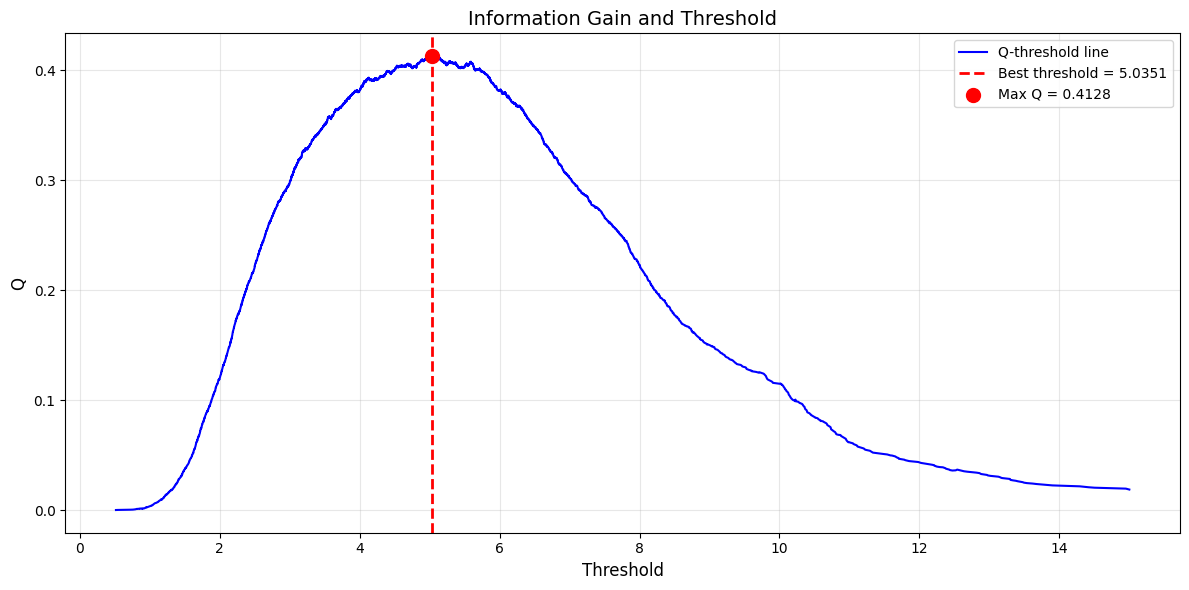

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
medinc = X['MedInc'].values
target = y

thresholds, q_values, best_threshold, best_q = find_best_split(feature_vector=medinc, target_vector=target, task="regression", feature_type="real")

plt.figure(figsize=(12, 6))
plt.plot(thresholds, q_values, 'b-', linewidth=1.5, label='Q-threshold line')
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Best threshold = {best_threshold:.4f}')
plt.scatter(best_threshold, best_q, color='red', s=100, zorder=5, label=f'Max Q = {best_q:.4f}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Q', fontsize=12)
plt.title('Information Gain and Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [37]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

feature_split = X.apply(lambda feature: find_best_split(feature, y, task="regression", feature_type="real")[2:], axis=0)

best_split_inds = feature_split.iloc[1].argmax()
best_split_feature = feature_split.columns[best_split_inds]
best_threshold, best_q = feature_split.iloc[:, best_split_inds]

print(f"Лучший предикат: {best_split_feature} <= {best_threshold:.4f} (Q = {best_q:.4f})")

Лучший предикат: MedInc <= 5.0351 (Q = 0.4128)


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [126]:
class DecisionTree:
    
    def __init__(
        self, 
        feature_types: Union[List[str], np.ndarray], 
        max_depth: int = None, 
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}
        
        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types
        
        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        
        # Переменная, если вы решите делать бонус
        self._feature_importances = {}
        

    def _fit_node(
        self, 
        sub_X: np.ndarray, 
        sub_y: np.ndarray, 
        node: dict
    ) -> None:
        
        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)
            
            # если разбиение не удалось
            if gini is not None and (gini_best is None or gini > gini_best):
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector <= threshold
                    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
                    # Обработка Nan
                    # Идея: смотрим, в какое поддерево ушло больше объектов и Nan пойдёт туда
                    # Почему так: 1. объект с пропуском скорее всего похож на большинство
                    #             2. если мы отправим его в меньшинство, то сильнее испортим неравенство классов -> больше ухудшим качество разбиения
                    nan = np.isnan(feature_vector)
                    if np.any(nan):
                        left_sum = np.sum(split[np.logical_not(nan)])
                        right_sum = np.sum(np.logical_not(split[np.logical_not(nan)]))
                        split[nan] = left_sum >= right_sum
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector == threshold
                    # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return
        
        # Подсчёт важности признака
        # Идея: будем суммировать по признакам такие штуки - (число_объектов_в_вершине * gini_best)
        # Почему так: 1. gini_best - прирост функции Q - чем лучше удалось разделить (чем больше прирост), тем признак важнее
        #             2. число_объектов_в_вершине - чем ближе к корню произошло разбиение, тем важнее оно было
        # Итого: близко к корню и большой gini_best - важный признак, далеко от корня и gini_best небольшой - не очень важный признак

        curr_importance = len(sub_y) * gini_best
        self._feature_importances[feature_best] = self._feature_importances.get(feature_best, 0) + curr_importance

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError
        
        # сохраняем поддерево, в которое пошло большинство, чтобы обрабатывать пропуски в predict
        n_left = np.sum(split)
        n_right = np.sum(np.logical_not(split))
        node["majority_child"] = "left" if n_left >= n_right else "right"

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node['type'] == 'terminal':
            return node['class']
        
        ind = node['feature_split']
        val = x[ind]
        # Обработка пропусков аналогично fit
        # isinstance чтобы категориальный признак случайно не попал в np.isnan
        if isinstance(val, float) and np.isnan(val):
            if node["majority_child"] == "left":
                return self._predict_node(x, node['left_child'])
            else:
                return self._predict_node(x, node['right_child'])
        if self._feature_types[ind] == 'real':
            if val <= node['threshold']:
                return self._predict_node(x, node['left_child'])
            return self._predict_node(x, node['right_child'])
        if val == node['category_split']:
            return self._predict_node(x, node['left_child'])
        return self._predict_node(x, node['right_child'])
        # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————


    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
            
        return np.array(predicted)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [127]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
data = pd.read_csv('students.csv', index_col=0)
X = data.iloc[:, :5]
y = data.iloc[:, 5]

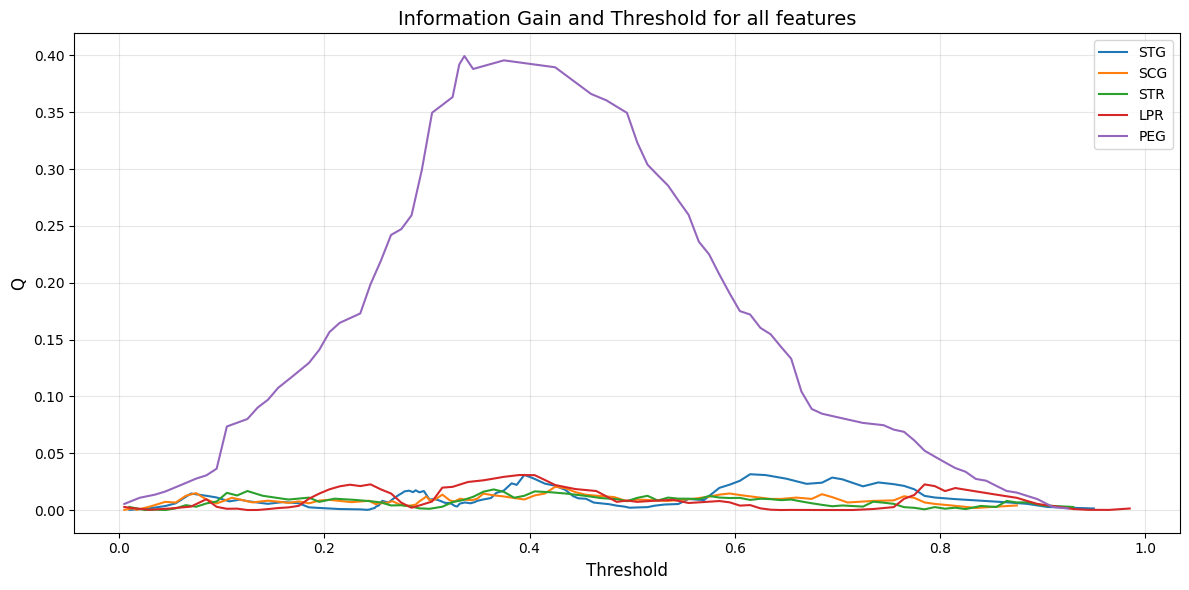

In [128]:
plt.figure(figsize=(12, 6))

for col in X.columns:
    thresholds, q_values, _, _ = find_best_split(X[col].values, y.values, task="classification", feature_type="real")
    plt.plot(thresholds, q_values, linewidth=1.5, label=col)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Q', fontsize=12)
plt.title('Information Gain and Threshold for all features', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

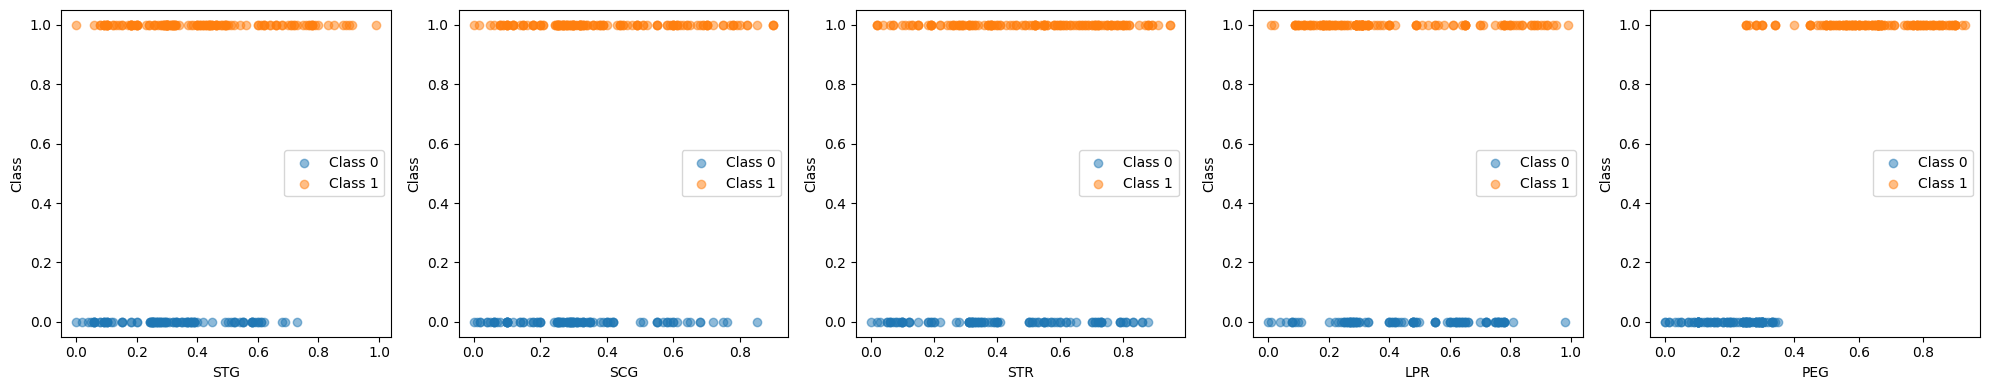

In [129]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(X.columns):
    for cls in [0, 1]:
        mask = y == cls
        axes[i].scatter(X.loc[mask, col], y[mask], alpha=0.5, label=f'Class {cls}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Class')
    axes[i].legend(loc='center right')

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
'''
Деление надо производить по признаку PEG (1 график). Результат согласуется с картиной для диаграмм рассеивания -
для PEG класс 0 находится сильно левее и практически не пересекается с классом 1, а для остальных признаков
значения обоих классов распределены примерно равномерно
Кривая для хорошего признака имеет ярковыраженный пик (похоже на нормальное распределение) - место, где лучший порог
хорошо поделит классы + чем дальше пороги от лучшего места тем хуже деление
Для плохих признаков кривые практически прямые (похоже на равномерное распределение) - все пороги можно считать
одинаково плохими
'''

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [55]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
data = pd.read_csv('agaricus-lepiota.data', header=None)
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
from sklearn.preprocessing import LabelEncoder
data = data.apply(LabelEncoder().fit_transform)
data.head()
#1 - poisonous, 0 - edible

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:, 1:].values, data.iloc[:, 0].values, test_size=0.5, random_state=67)

tree = DecisionTree(feature_types=['categorical'] * (data.shape[1] - 1), task="classification")
tree.fit(X_train, y_train)
predict_train = tree.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, predict_train)}")

predict_test = tree.predict(X_test)
print(f"Test accuracy:  {accuracy_score(y_test, predict_test)}")
# какие же мы крутые и (скорее всего) переобученные

Train accuracy: 1.0
Test accuracy:  1.0


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [64]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [65]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

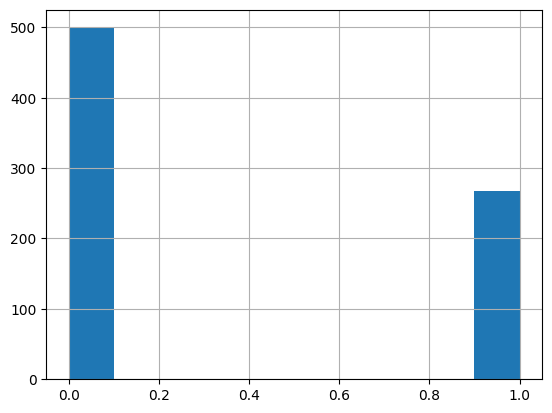

In [66]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)
X_train_train, X_train_valid, y_train_train, y_train_valid = train_test_split(X_train, y_train, test_size=0.3, random_state=67)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [95]:
from sklearn.metrics import f1_score
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————

max_depth = np.arange(1, 25, 1)
min_samples_leaf = np.arange(1, 25, 1)

best_f1 = 0
best_max_depth = 0
best_samples_leaf = 0
for i in min_samples_leaf:
    for j in max_depth:
        dt_class = DecisionTreeClassifier(max_depth=j, min_samples_leaf=i)
        dt_class.fit(X_train_train, y_train_train)
        y_pred = dt_class.predict(X_train_valid)
        curr_f1 = f1_score(y_train_valid, y_pred)
        if best_f1 < curr_f1:
            best_f1 = curr_f1
            best_max_depth = j
            best_samples_leaf = i
print(f"max_depth = {best_max_depth}; samples_leaf = {best_samples_leaf}")
print(f"f1 = {best_f1}")

max_depth = 3; samples_leaf = 21
f1 = 0.6792452830188679


In [100]:
# обучаем итоговое дерево
max_depth = 3
min_samples_leaf = 21

dt_class = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
dt_class.fit(X_train, y_train)
y_pred = dt_class.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred):.4f}")
print(f"precision = {precision_score(y_test, y_pred):.4f}")
print(f"recall = {recall_score(y_test, y_pred):.4f}")
print(f"roc_auc = {roc_auc_score(y_test, y_pred):.4f}")


accuracy = 0.7489
precision = 0.7258
recall = 0.5233
roc_auc = 0.7030


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [102]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
bagging_class = BaggingClassifier(n_estimators=50)
bagging_class.fit(X_train, y_train)

y_pred = bagging_class.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred):.4f}")
print(f"precision = {precision_score(y_test, y_pred):.4f}")
print(f"recall = {recall_score(y_test, y_pred):.4f}")
print(f"roc_auc = {roc_auc_score(y_test, y_pred):.4f}")

accuracy = 0.7359
precision = 0.7049
recall = 0.5000
roc_auc = 0.6879


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [106]:
from sklearn.model_selection import cross_val_score
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
max_depth = np.arange(1, 25, 1)
min_samples_split = np.arange(2, 25, 1)

best_f1 = 0
best_max_depth = 0
best_samples_split = 0
for i in min_samples_split:
    for j in max_depth:
        rf_class = RandomForestClassifier(n_estimators=50, max_depth=j, min_samples_split=i, random_state=67)
        scores = cross_val_score(rf_class, X_train, y_train, cv=3, scoring='f1')

        curr_f1 = np.mean(scores)
        if best_f1 < curr_f1:
            best_f1 = curr_f1
            best_max_depth = j
            best_samples_split = i
print(f"max_depth = {best_max_depth}; samples_split = {best_samples_split}")
print(f"f1 = {best_f1}")

max_depth = 8; samples_split = 2
f1 = 0.6422321549505621


In [ ]:
max_depth = 8
min_samples_split = 2

rf_class = RandomForestClassifier(n_estimators=50, max_depth=max_depth, min_samples_split=min_samples_split, random_state=67)
rf_class.fit(X_train, y_train)
y_pred = rf_class.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred):.4f}")
print(f"precision = {precision_score(y_test, y_pred):.4f}")
print(f"recall = {recall_score(y_test, y_pred):.4f}")
print(f"roc_auc = {roc_auc_score(y_test, y_pred):.4f}")
# В целом метрики вышли примерно одинаковыми, но DecisionTree по всем метрикам чуть-чуть лучше остальных

accuracy = 0.7359
precision = 0.7273
recall = 0.4651
roc_auc = 0.6808


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

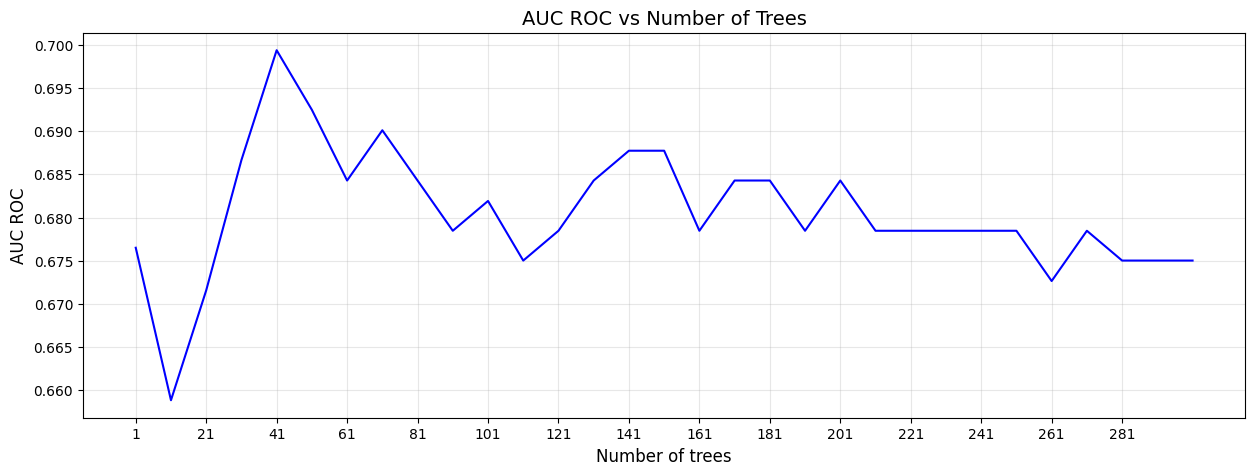

In [ ]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
n_trees = np.arange(1, 302, 10)
auc_scores = []

for i in n_trees:
    rf = RandomForestClassifier(n_estimators=i, max_depth=best_max_depth, min_samples_split=best_samples_split, random_state=67)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    auc_scores.append(roc_auc_score(y_test, y_pred))

plt.figure(figsize=(15, 5))
plt.plot(n_trees, auc_scores, 'b-', linewidth=1.5)
plt.xlabel('Number of trees', fontsize=12)
plt.ylabel('AUC ROC', fontsize=12)
plt.title('AUC ROC vs Number of Trees', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(1, 301, 20))
plt.show()

# До какого-то момента (в нашем случае до 41) auc-roc растёт, а дальше начинает падать (но держаться примерно на одном уровне)
# Вывод: в данном случае имеет смыс взяь n_estimators = 41 или в окресностях 41, дальнейшее увеличение числа деревьев смысла не имеет

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

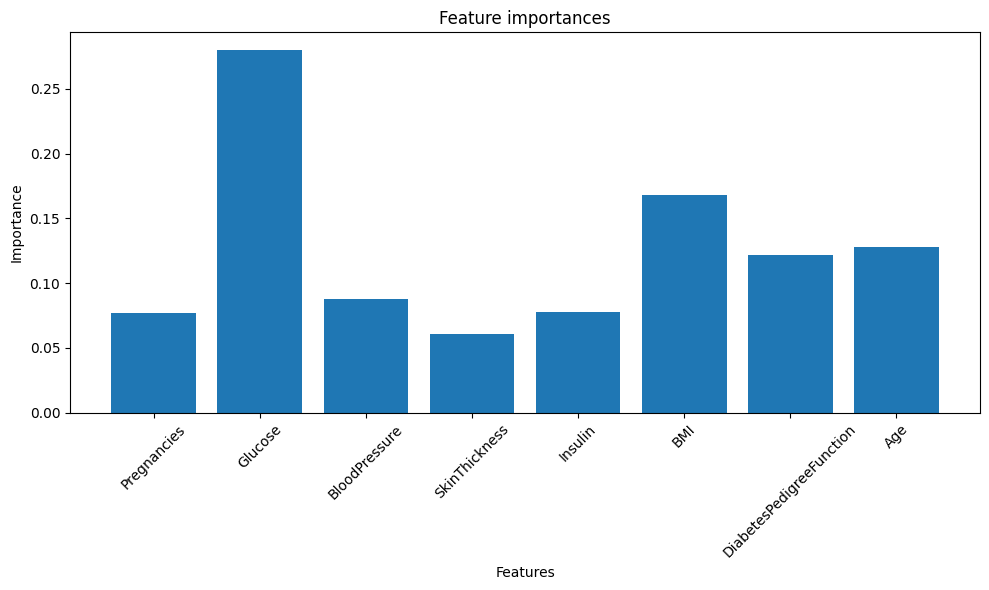

In [119]:
# ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
rf = RandomForestClassifier(n_estimators=60, max_depth=best_max_depth, min_samples_split=best_samples_split, random_state=67)
rf.fit(X_train, y_train)
importances = rf.feature_importances_

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), X.columns, rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature importances')
plt.tight_layout()
plt.show()
# Самым важным признаком оказался Glucose (логично) с важностью более 30%
# Далее по важности идут BMI, Age и DiabetesPedigreeFunction